# DA6401 Assignment 1 - Part 2: Experiments and Analysis

**Student Name:** Anirudh Bharadwaj  
**Roll Number:** EE25S046  
**Date:** March 7, 2026

## Overview

This notebook contains the complete implementation and experiments for Part 2 of the assignment. The assignment involves the following questions:

1.  Dataset Exploration and Visualization (Done)
2.  Hyperparameter Sweep Configuration  (Done - Corrected )
3.  Optimizer Showdown (Yet to Do)
4.  Vanshing Gradient Analysis (yet to do)
5.  Dead Neuron Investigation 
6.  Loss Function Comparision
7.  Global Performance Analysis (In Wandb)
8.  Error Analysis
9.  Weight Initialization & Symmetry
10. The Fashion-MNIST Transfer Challenge

All experiments are logged to Weights & Biases (W&B) for tracking and visualization.

## Setup and Imports

Importing all necessary libraries and setting up the environment.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add src to path as it is useful for imports in the Jupyter Noteebook
sys.path.insert(0, os.path.abspath('../src'))
### The Custom Scipts 
from utils.data_loader import load_mnist, load_fashion_mnist
from ann.neural_network import NeuralNetwork
import wandb
# Set random seed for reproducibility
np.random.seed(24)

---

# Question 2.1: Dataset Exploration and Visualization

Let's load the MNIST dataset and explore its properties. We'll visualize sample images from each class to understand what we're working with.

Step 1: Load the MNIST Dataset

First, let's load the data and check its dimensions and other properties.

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = load_mnist()

print(
    f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}\n"
    f"Input dim: {X_train.shape[1]} | Classes: {len(np.unique(y_train))}\n"
    f"dtype: {X_train.dtype} | range: [{X_train.min():.3f}, {X_train.max():.3f}]"
)


Train: 54,000 | Val: 6,000 | Test: 10,000
Input dim: 784 | Classes: 10
dtype: float32 | range: [0.000, 255.000]


Step 2: Visualize Sample Images from Each Class & Log them in Wandb Table 

creating a grid showing sample images from each digit (0-9).

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.
wandb: Currently logged in as: anicosmos (anicosmos-iitm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Logging images to W&B...


dataset/input_dim,▁
dataset/num_classes,▁
dataset/test_size,▁
dataset/train_size,▁
dataset/val_size,▁
dataset/input_dim,784
dataset/num_classes,10
dataset/test_size,10000
dataset/train_size,54000
dataset/val_size,6000


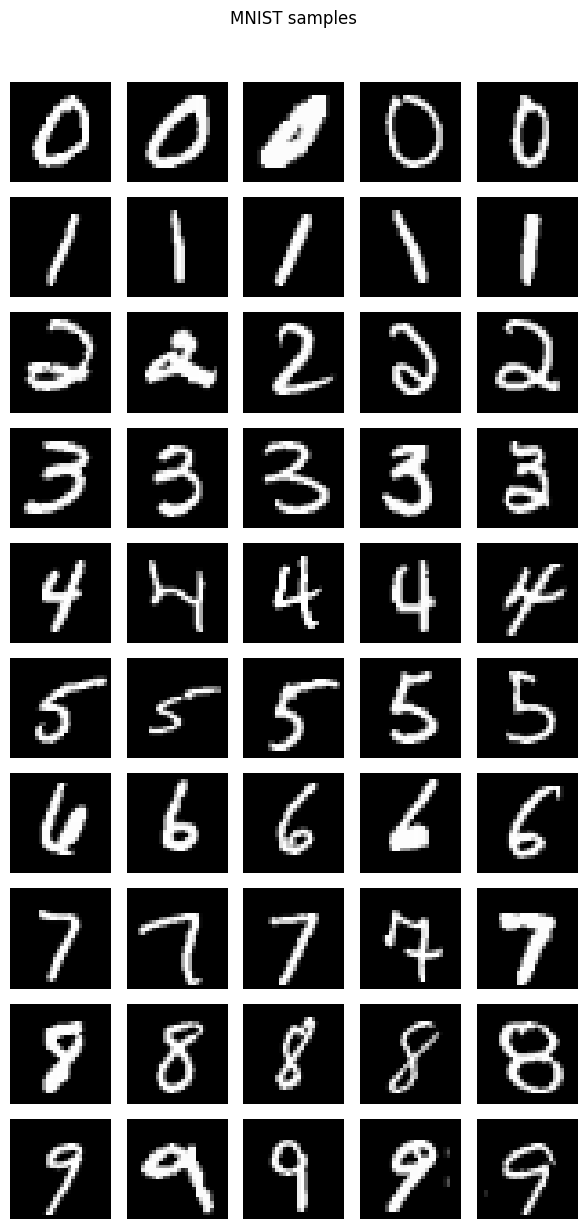

In [3]:
def visualize_log_mnist_samples(X, y, samples_per_class=5, save_path=None):
    
    table = wandb.Table(columns=["digit", "image"])
    num_classes = 10
    fig, axes = plt.subplots(
        num_classes,
        samples_per_class,
        figsize=(samples_per_class * 1.2, num_classes * 1.2),
        squeeze=False,
    )

    for digit in range(num_classes):
        idx = np.where(y == digit)[0]
        chosen = np.random.choice(idx, size=min(samples_per_class, len(idx)), replace=False)

        for col in range(samples_per_class):
            ax = axes[digit, col]
            ax.axis("off")
            if col < len(chosen):
                img = X[chosen[col]].reshape(28, 28)
                ax.imshow(img, cmap="gray")
                table.add_data(digit, wandb.Image(img))

        axes[digit, 0].set_ylabel(str(digit), rotation=0, labelpad=10, va="center")

    fig.suptitle("MNIST samples", y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig,table

run = wandb.init(
    project="da6401_a1",
    name="data_exploration_mnist",
    tags=["exploration", "visualization","table"],
    notes="Exploring MNIST dataset"
)

if wandb.run is not None:
    print("Logging images to W&B...")
    fig,table = visualize_log_mnist_samples(X_train, y_train, samples_per_class=5)
    wandb.log({"mnist_samples": table})
    # plt.close(fig)
    # Log dataset & statistics Also 

    wandb.log({
        "dataset/train_size": len(X_train),
        "dataset/val_size": len(X_val),
        "dataset/test_size": len(X_test),
        "dataset/num_classes": len(np.unique(y_train)),
        "dataset/input_dim": X_train.shape[1]
    })
    wandb.finish()

plt.show()

Here we can see that maybe a 5 can be misinterpreted as a 6 , in this image 8 might be misinterpreted as a 0 , 9 can be interpreted as a 1 


# Question 2.2: Hyperparameter Sweep Configuration

Now we will try to set up a  hyperparameter sweep using W&B. We'll explore different combinations of the following parameters:
- Number of hidden layers
- Hidden layer sizes  
- Activation functions
- Weight initialization strategies
- Optimizers
- Learning rates
- Batch sizes

This will help us identify the best configuration for our neural network.

### Step 1: Define Helper Functions for Training

First, let's create helper functions to convert our data and train the model.

In [3]:
class Args:
    """Simple class to mimic our argparse arguments"""
    def __init__(self, **kwargs):
        for key, value in kwargs.items():
            setattr(self, key, value)


def train_model_with_wandb(config=None):
    """
    Training function for W&B sweeps (using the Same Functiion ad the wandb demo but with the NeuralNetwork class instead of PyTorch)
    This function will be called by W&B agent for each sweep configuration
    """
    # Initialize W&B run
    run = wandb.init(config=config)
    if wandb.run is not None:
        # Access config
        cfg = wandb.config
        
        print(f"Training with configuration:")
        print(f"Optimizer: {cfg.optimizer}")
        print(f"Learning Rate: {cfg.learning_rate}")
        print(f"Hidden Layers: {cfg.num_layers}")
        print(f"Hidden Size: {cfg.hidden_size}")
        print(f"Activation: {cfg.activation}")
        print(f"Weight Init: {cfg.weight_init}")
        print(f"Batch Size: {cfg.batch_size}")
        print(f"Epochs: {cfg.epochs}")
        
        # Create args object for NeuralNetwork
        args = Args(
            dataset='mnist',
            epochs=cfg.epochs,
            batch_size=cfg.batch_size,
            learning_rate=cfg.learning_rate,
            optimizer=cfg.optimizer,
            num_layers=cfg.num_layers,
            hidden_size=cfg.hidden_size,
            activation=cfg.activation,
            weight_init=cfg.weight_init,
            loss=cfg.loss,
            weight_decay=0.0,
            wandb_project='da6401_a1',
            wandb_entity=None,
            model_save_path='./models/sweep_model.npy'
        )
        
        # Initialize model
        nn = NeuralNetwork(args)
        
        # Train the model
        history = nn.train(X_train, y_train, X_val, y_val,use_wandb=True)
        
        # Evaluate on test set
        test_metrics = nn.evaluate(X_test, y_test)
        
        print(f"\nTest  accuracy={test_metrics['accuracy']:.4f}  "
          f"loss={test_metrics['loss']:.4f}\n"
          f"F1-Score ={test_metrics['f1']:.4f}\n"
          f"Recall ={test_metrics['recall']:.4f}\n")

    
        if wandb.run is not None:
            wandb.log({'final_test_accuracy': test_metrics['accuracy'],
                   'final_test_loss':     test_metrics['loss'],
                   'final_test_f1':       test_metrics['f1'],
                   'final_test_recall':   test_metrics['recall']})
        
        print(f"\nTraining completed!")
        print(f"  Final Test Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"  Final Test Loss: {test_metrics['loss']:.4f}")
        print(f"  Final Test F1-Score: {test_metrics['f1']:.4f}")
        print(f"  Final Test Recall: {test_metrics['recall']:.4f}")
        return test_metrics['accuracy']

### Configure the Hyperparameter Sweep

Defining the sweep configuration. We'll use wandb's grid search to systematically explore the hyperparameter space.

Starting Small 

In [ ]:
# First attempt 

sweep_config_v1 = {
    'method': 'grid',
    'metric': {
        'name': 'final_test_f1', ## This was high in the first run 
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'values': [0.001]  # Let's try two learning rates
        },
        'optimizer': {
            'values': ['sgd']  # Two optimizers
        },
        'activation': {
            'values': ['relu']  # Two activations
        },
        'num_layers': {
            'values': [2,3] # Fixed for now
        },
        'hidden_size': {
            # 'values': ['128,64','128,64,32']  # if we want to pass multiple hidden layer configurations as comma-separated strings
            'values': [128,64,32] ## But this should be fine 
        },
        'loss': {
            'value': 'cross_entropy'  # Fixed for now
        },
        'weight_init': {
            'value': 'xavier'  # Fixed for now
        },
        'batch_size': {
            'value': 32  # Fixed for now
        },
        'epochs': {
            'value': 5  # Just 5 epochs for quick testing
        }
    }
}
sweep_id = wandb.sweep(sweep_config_v1, project='da6401_a1')
print(f"Created sweep with ID: {sweep_id}")
wandb.agent(sweep_id, train_model_with_wandb, count=2)


Create sweep with ID: 8nj4w469
Sweep URL: https://wandb.ai/anicosmos-iitm/da6401_a1/sweeps/8nj4w469
Created sweep with ID: 8nj4w469


wandb: Agent Starting Run: 0i1q6obg with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 5
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	loss: cross_entropy
wandb: 	num_layers: 2
wandb: 	optimizer: sgd
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: sgd
Learning Rate: 0.001
Hidden Layers: 2
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 5
Epoch 1/5  loss=1.1023  train_acc=0.8069  val_acc=0.8753  val_loss=0.5287
Logging epoch 1 metrics to W&B...
Epoch 2/5  loss=0.4246  train_acc=0.8931  val_acc=0.9000  val_loss=0.4298
Logging epoch 2 metrics to W&B...
Epoch 3/5  loss=0.3245  train_acc=0.9147  val_acc=0.9143  val_loss=0.3651
Logging epoch 3 metrics to W&B...
Epoch 4/5  loss=0.2673  train_acc=0.9277  val_acc=0.9205  val_loss=0.3440
Logging epoch 4 metrics to W&B...
Epoch 5/5  loss=0.2317  train_acc=0.9357  val_acc=0.9252  val_loss=0.3224
Logging epoch 5 metrics to W&B...

Test  accuracy=0.9283  loss=0.2944
F1-Score =0.9274
Recall =0.9276


Training completed!
  Final Test Accuracy: 0.9283
  Final Test Loss: 0.2944
  Final Test F1-Score: 0.9274
  Final Test Recall: 0.9276


epoch,▁▃▅▆█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▅█▄▁▃
grad_norm_layer_1,▄█▂▁▂
train_accuracy,▁▆▇██
train_loss,█▃▂▁▁
val_accuracy,▁▄▆▇█
+1,...


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: f350woo3 with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 5
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	loss: cross_entropy
wandb: 	num_layers: 3
wandb: 	optimizer: sgd
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: sgd
Learning Rate: 0.001
Hidden Layers: 3
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 5
Epoch 1/5  loss=0.9299  train_acc=0.8441  val_acc=0.9028  val_loss=0.4135
Logging epoch 1 metrics to W&B...
Epoch 2/5  loss=0.2923  train_acc=0.9212  val_acc=0.9178  val_loss=0.3223
Logging epoch 2 metrics to W&B...
Epoch 3/5  loss=0.2038  train_acc=0.9405  val_acc=0.9275  val_loss=0.2832
Logging epoch 3 metrics to W&B...
Epoch 4/5  loss=0.1612  train_acc=0.9521  val_acc=0.9337  val_loss=0.2565
Logging epoch 4 metrics to W&B...
Epoch 5/5  loss=0.1335  train_acc=0.9594  val_acc=0.9397  val_loss=0.2430
Logging epoch 5 metrics to W&B...

Test  accuracy=0.9438  loss=0.2328
F1-Score =0.9429
Recall =0.9431


Training completed!
  Final Test Accuracy: 0.9438
  Final Test Loss: 0.2328
  Final Test F1-Score: 0.9429
  Final Test Recall: 0.9431


epoch,▁▃▅▆█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▅█▁▁▄
grad_norm_layer_1,▅█▁▁▅
grad_norm_layer_2,▅█▂▁▅
train_accuracy,▁▆▇██
train_loss,█▂▂▁▁
+2,...


In [7]:
## More Parameters , the 100 RUN! 

sweep_config_comprehensive = {
    'method': 'bayes', ## AI suggested this method to explore the space more efficiently
    'metric': {
        'name': 'final_test_f1', 
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'values': [0.001, 0.01,0.1]  # 3 values , maybe 0.1 , we will get dead neurons
        },
        'optimizer': {
            'values': ['sgd', 'momentum', 'rmsprop', 'nag']  # 4 optimizers
        },
        'activation': {
            'values': ['relu', 'sigmoid', 'tanh']  # 3 activations 
        },
        'num_layers': {
            'values': [2, 3, 4, 5, 6]  # 5 values , maybe at 6 we get vanishing gradients 
        },
        'hidden_size': {
            'values': [128]  # 1 size
        },
        'weight_init': {
            'values': ['random', 'xavier']  # 2 init methods 
        },
        'batch_size': {
            'values': [32, 64]  # 2 batch sizes , 128 might max out my memory 
        },
        'epochs': {
            'value': 10  # Fixed at 10 epochs because it worked ok for the first run 
        }
    }
}

### Toooo many runs , running a subset of them , only 100 runs 
sweep_id100 = wandb.sweep(sweep_config_comprehensive, project='da6401_a1')

wandb.agent(sweep_id100, train_model_with_wandb, count=100)

Create sweep with ID: udxqgdf0
Sweep URL: https://wandb.ai/anicosmos-iitm/da6401_a1/sweeps/udxqgdf0


wandb: Agent Starting Run: 5tsvii32 with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 2
wandb: 	optimizer: rmsprop
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: rmsprop
Learning Rate: 0.001
Hidden Layers: 2
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=0.2383  train_acc=0.9686  val_acc=0.9667  val_loss=0.2394
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=0.1044  train_acc=0.9799  val_acc=0.9753  val_loss=0.4317
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=0.0787  train_acc=0.9835  val_acc=0.9743  val_loss=1.1168
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=0.0631  train_acc=0.9877  val_acc=0.9778  val_loss=2.4282
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.0542  train_acc=0.9882  val_acc=0.9775  val_loss=5.8402
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=0.0470  train_acc=0.9883  val_acc=0.9757  val_loss=9.5411
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=0.0382  train_acc=0.9925  val_acc=0.9802  val_loss=11.2224
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=0.0345  train_acc=0.9921  val_acc=0.9783  val_loss=16

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▂▃▄▅█▁▂▁▁▁
grad_norm_layer_1,▂▂▂▃█▁▁▁▁▁
train_accuracy,▁▄▅▆▆▆▇▇██
train_loss,█▄▃▂▂▂▁▁▁▁
val_accuracy,▁▅▄▆▆▅▇▆██
+1,...


wandb: Agent Starting Run: jkm4mvlf with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 64
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 3
wandb: 	optimizer: sgd
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


...

Training with configuration:
Optimizer: nag
Learning Rate: 0.01
Hidden Layers: 5
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=0.3209  train_acc=0.9586  val_acc=0.9573  val_loss=0.0218
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=0.1280  train_acc=0.9751  val_acc=0.9718  val_loss=0.0283
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=0.0911  train_acc=0.9790  val_acc=0.9720  val_loss=0.0131
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=0.0707  train_acc=0.9821  val_acc=0.9727  val_loss=0.0276
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.0575  train_acc=0.9885  val_acc=0.9787  val_loss=0.0199
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=0.0466  train_acc=0.9866  val_acc=0.9743  val_loss=0.0235
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=0.0401  train_acc=0.9904  val_acc=0.9755  val_loss=0.0131
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=0.0331  train_acc=0.9918  val_acc=0.9768  val_loss=0.0125
L

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▂▃▄▇▄▁▁█▁▁
grad_norm_layer_1,▂▂▃▆▄▁▁█▁▁
grad_norm_layer_2,▂▂▃▆▄▁▁█▁▁
grad_norm_layer_3,▂▂▄▇▅▁▁█▁▁
grad_norm_layer_4,▂▂▄▇▆▁▁█▁▁
+4,...


wandb: Agent Starting Run: qnnzl0f4 with config:
wandb: 	activation: relu
wandb: 	batch_size: 64
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 4
wandb: 	optimizer: nag
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: nag
Learning Rate: 0.001
Hidden Layers: 4
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 64
Epochs: 10
Epoch 1/10  loss=1.1193  train_acc=0.8776  val_acc=0.8850  val_loss=0.1774
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=0.3571  train_acc=0.9139  val_acc=0.9187  val_loss=0.0934
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=0.2779  train_acc=0.9276  val_acc=0.9323  val_loss=0.0619
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=0.2361  train_acc=0.9376  val_acc=0.9412  val_loss=0.0593
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.2069  train_acc=0.9445  val_acc=0.9472  val_loss=0.0548
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=0.1843  train_acc=0.9504  val_acc=0.9500  val_loss=0.0555
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=0.1670  train_acc=0.9514  val_acc=0.9513  val_loss=0.0479
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=0.1522  train_acc=0.9599  val_acc=0.9593  val_loss=0.0432


epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▃▂▄▄▃▁▂▅█▆
grad_norm_layer_1,▂▂▆▄▄▁▂▇█▅
grad_norm_layer_2,▂▂█▃▄▁▂▆█▅
grad_norm_layer_3,▄▂█▃▄▁▂▄▆▄
train_accuracy,▁▄▅▆▆▇▇▇██
+3,...


## Hyper Parameter 2 


In [ ]:
## More Parameters , the 100 RUN! With more hidden layer variations  

sweep_config_comprehensive = {
    'method': 'bayes', ## AI suggested this method to explore the space more efficiently
    'metric': {
        'name': 'final_test_f1', 
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'values': [0.001, 0.005,0.01]  # 4 values , maybe 0.1 , we will get dead neurons
        },
        'optimizer': {
            'values': ['sgd', 'momentum', 'rmsprop', 'nag']  # 4 optimizers
        },
        'activation': {
            'values': ['relu', 'sigmoid', 'tanh']  # 3 activations 
        },
        'num_layers': {
            'values': [2, 3, 4, 5, 6]  # 5 values , maybe at 6 we get vanishing gradients 
        },
        'loss': {
            'value': 'cross_entropy'  # Fixed for now
        },
        'hidden_size': {
            'values': [64,128]  # 2 sizes
        },
        'weight_init': {
            'values': ['xavier']  # 1 init methods 
        },
        'batch_size': {
            'values': [32, 64]  # 2 batch sizes , 128 might max out my memory 
        },
        'epochs': {
            'value': 10  # Fixed at 10 epochs because it worked ok for the first run 
        }
    }
}

### Toooo many runs , running a subset of them , only 100 runs 
sweep_id100 = wandb.sweep(sweep_config_comprehensive, project='da6401_a1')

wandb.agent(sweep_id100, train_model_with_wandb, count=100)

Create sweep with ID: x0tz4fmr
Sweep URL: https://wandb.ai/anicosmos-iitm/da6401_a1/sweeps/x0tz4fmr


wandb: Agent Starting Run: pt1zai13 with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.01
wandb: 	loss: cross_entropy
wandb: 	num_layers: 6
wandb: 	optimizer: nag
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: nag
Learning Rate: 0.01
Hidden Layers: 6
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 10


g:\ani\da6401_assignment_1\src\ann\activations.py:53: RuntimeWarning: invalid value encountered in subtract
  exp_z = xp.exp(z - xp.max(z, axis=1, keepdims=True))


Epoch 1/10  loss=nan  train_acc=0.0987  val_acc=0.0987  val_loss=nan
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=nan  train_acc=0.0987  val_acc=0.0987  val_loss=nan
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=nan  train_acc=0.0987  val_acc=0.0987  val_loss=nan
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=nan  train_acc=0.0987  val_acc=0.0987  val_loss=nan
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=nan  train_acc=0.0987  val_acc=0.0987  val_loss=nan
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=nan  train_acc=0.0987  val_acc=0.0987  val_loss=nan
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=nan  train_acc=0.0987  val_acc=0.0987  val_loss=nan
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=nan  train_acc=0.0987  val_acc=0.0987  val_loss=nan
Logging epoch 8 metrics to W&B...
Epoch 9/10  loss=nan  train_acc=0.0987  val_acc=0.0987  val_loss=nan
Logging epoch 9 metrics to W&B...
Epoch 10/10  loss=nan  train_acc=0.0987  val_acc=0.0987  val_loss=nan
Log

...

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▅▆▃▃█▃▂▂▃▁
grad_norm_layer_1,▅▅▃▂█▃▁▁▂▁
grad_norm_layer_2,█▅▃▂█▅▁▂▂▂
train_accuracy,▁▅▆▇▇▇▇███
train_loss,█▃▂▂▂▁▁▁▁▁
+2,...


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: oqrwthrf with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 64
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	loss: cross_entropy
wandb: 	num_layers: 3
wandb: 	optimizer: nag
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: nag
Learning Rate: 0.001
Hidden Layers: 3
Hidden Size: 128
Activation: sigmoid
Weight Init: xavier
Batch Size: 64
Epochs: 10
Epoch 1/10  loss=2.2611  train_acc=0.2482  val_acc=0.3757  val_loss=2.1994
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=2.1009  train_acc=0.5042  val_acc=0.5677  val_loss=1.9688
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=1.7568  train_acc=0.6233  val_acc=0.6857  val_loss=1.5234
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=1.2978  train_acc=0.7189  val_acc=0.7495  val_loss=1.1011
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.9523  train_acc=0.7906  val_acc=0.8238  val_loss=0.8276
Logging epoch 5 metrics to W&B...


g:\ani\da6401_assignment_1\src\ann\activations.py:49: RuntimeWarning: overflow encountered in exp
  1.0 / (1.0 + xp.exp(-z)),
g:\ani\da6401_assignment_1\src\ann\activations.py:50: RuntimeWarning: overflow encountered in exp
  xp.exp(z) / (1.0 + xp.exp(z)))
g:\ani\da6401_assignment_1\src\ann\activations.py:50: RuntimeWarning: invalid value encountered in divide
  xp.exp(z) / (1.0 + xp.exp(z)))


Epoch 6/10  loss=0.7384  train_acc=0.8383  val_acc=0.8542  val_loss=0.6642
Logging epoch 6 metrics to W&B...


## Analysis on the Hyperparameter Runs 
We have identified a Run that has potential to be the best model, we rerun that and store that for the best_weights.npy , Might have to modify the test score objective as F1 score 


### Optimizer Showdown 
rooting for RMSprop 


In [12]:
### Targeted Sweep : Optimizers Showdown 


sweep_config_optimizer_showdown = {
    'method': 'grid', ## AI suggested this method to explore the space more efficiently
    'metric': {
        'name': 'final_test_f1', 
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'values': [0.001, 0.0005,0.002,0.01] # Trying various lr so that rmsprop will work  
        },
        'optimizer': {
            'values': ['sgd', 'momentum', 'rmsprop', 'nag']  # 4 optimizers
        },
        'activation': {
            'values': ['relu']  
        },
        'num_layers': {
            'values': [3]  # 5 values , maybe at 6 we get vanishing gradients 
        },
        'hidden_size': {
            'values': [128]  # 1 size
        },
        'weight_init': {
            'values': ['xavier']  # 1 init method 
        },
        'batch_size': {
            'values': [32]  # 1 batch size , 128 might max out my memory 
        },
        'epochs': {
            'value': 10  # Fixed at 10 epochs because it worked ok for the first run 
        }
    }
}

### Toooo many runs , running a subset of them , only 100 runs 
sweep_id_optshowdown2 = wandb.sweep(sweep_config_optimizer_showdown, project='da6401_a1')

wandb.agent(sweep_id_optshowdown2, train_model_with_wandb)  # 8 runs for 4 optimizers x 2 learning rates

Create sweep with ID: hhps98rj
Sweep URL: https://wandb.ai/anicosmos-iitm/da6401_a1/sweeps/hhps98rj


wandb: Agent Starting Run: ahs9u0be with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 3
wandb: 	optimizer: sgd
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: sgd
Learning Rate: 0.001
Hidden Layers: 3
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=2.1047  train_acc=0.6084  val_acc=0.6127  val_loss=2.8905
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=1.3186  train_acc=0.7740  val_acc=0.7838  val_loss=0.4588
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=0.7448  train_acc=0.8378  val_acc=0.8482  val_loss=0.2824
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=0.5499  train_acc=0.8670  val_acc=0.8763  val_loss=0.2118
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.4619  train_acc=0.8797  val_acc=0.8890  val_loss=0.1872
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=0.4130  train_acc=0.8886  val_acc=0.9002  val_loss=0.1575
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=0.3821  train_acc=0.8955  val_acc=0.9058  val_loss=0.1526
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=0.3595  train_acc=0.9004  val_acc=0.9092  val_loss=0.1401


epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▄▅▅▁█▂▇▃▁▂
grad_norm_layer_1,▂▄▃▁█▂▅▄▁▁
grad_norm_layer_2,▂▅▃▁█▂▄▄▁▁
train_accuracy,▁▅▆▇▇█████
train_loss,█▅▃▂▂▁▁▁▁▁
+2,...


wandb: Agent Starting Run: ljcefpfe with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 3
wandb: 	optimizer: momentum
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


...

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▂▄▁▁▁▂█▂▁▁
grad_norm_layer_1,▁▃▁▁▁▃█▂▁▁
grad_norm_layer_2,▂▃▁▁▁▄█▃▁▁
train_accuracy,█▇█▅█▂▄▃▅▁
train_loss,▂▁▂▃▃▅▅▆▇█
+2,...


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: i1ufih5b with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.01
wandb: 	num_layers: 3
wandb: 	optimizer: nag
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: nag
Learning Rate: 0.01
Hidden Layers: 3
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=0.2920  train_acc=0.9623  val_acc=0.9617  val_loss=0.0441
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=0.1184  train_acc=0.9698  val_acc=0.9652  val_loss=0.0253
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=0.0842  train_acc=0.9824  val_acc=0.9763  val_loss=0.0194
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=0.0642  train_acc=0.9840  val_acc=0.9742  val_loss=0.0124
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.0519  train_acc=0.9876  val_acc=0.9760  val_loss=0.0084
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=0.0415  train_acc=0.9919  val_acc=0.9775  val_loss=0.0124
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=0.0340  train_acc=0.9904  val_acc=0.9737  val_loss=0.0156
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=0.0272  train_acc=0.9944  val_acc=0.9768  val_loss=0.0083
L

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▄▅█▅▂▂▁▁▅▁
grad_norm_layer_1,▄▄█▄▂▂▂▁▅▁
grad_norm_layer_2,▄▄█▃▂▂▁▁▅▁
train_accuracy,▁▃▅▆▆▇▇███
train_loss,█▄▃▂▂▂▁▁▁▁
+2,...


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


### Activations 


In [9]:
### Targeted Sweep : OVanishing Showdown 


sweep_config_vanishing_grads = {
    'method': 'grid', 
    'metric': {
        'name': 'final_test_f1', 
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'values': [0.001]  # 1 value 
        },
        'optimizer': {
            'values': ['rmsprop']  # 4 optimizers
        },
        'activation': {
            'values': ['relu','sigmoid']  
        },
        'num_layers': {
            'values': [2,3,4]  # 5 values , maybe at 6 we get vanishing gradients 
        },
        'hidden_size': {
            'values': [128]  # 1 size
        },
        'weight_init': {
            'values': ['xavier']  # 1 init method 
        },
        'batch_size': {
            'values': [32]  # 1 batch size , 128 might max out my memory 
        },
        'epochs': {
            'value': 10  # Fixed at 10 epochs because it worked ok for the first run 
        }
    }
}

### Toooo many runs , running a subset of them , only 100 runs 
sweep_id_vanishing = wandb.sweep(sweep_config_vanishing_grads, project='da6401_a1')

wandb.agent(sweep_id_vanishing, train_model_with_wandb, count=6)  # 6 runs for 3 layer configs x 2 activations

Create sweep with ID: 2n44m2fg
Sweep URL: https://wandb.ai/anicosmos-iitm/da6401_a1/sweeps/2n44m2fg


wandb: Agent Starting Run: y0nj9jec with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 2
wandb: 	optimizer: rmsprop
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: rmsprop
Learning Rate: 0.001
Hidden Layers: 2
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=0.2448  train_acc=0.9594  val_acc=0.9582  val_loss=0.3428
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=0.1093  train_acc=0.9729  val_acc=0.9712  val_loss=0.7055
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=0.0811  train_acc=0.9846  val_acc=0.9772  val_loss=1.5902
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=0.0644  train_acc=0.9842  val_acc=0.9750  val_loss=3.7849
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.0531  train_acc=0.9889  val_acc=0.9780  val_loss=7.5123
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=0.0456  train_acc=0.9899  val_acc=0.9793  val_loss=14.6121
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=0.0391  train_acc=0.9932  val_acc=0.9822  val_loss=17.5018
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=0.0345  train_acc=0.9943  val_acc=0.9820  val_loss=1

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▄▅▂▄▁▄█▁▁▁
grad_norm_layer_1,▃▃▂▄▁▃█▁▁▁
train_accuracy,▁▄▆▆▇▇████
train_loss,█▄▃▂▂▂▁▁▁▁
val_accuracy,▁▅▇▆▇▇██▇▇
+1,...


wandb: Agent Starting Run: slohgtip with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 3
wandb: 	optimizer: rmsprop
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


...

Training with configuration:
Optimizer: rmsprop
Learning Rate: 0.001
Hidden Layers: 3
Hidden Size: 128
Activation: sigmoid
Weight Init: xavier
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=0.5052  train_acc=0.9273  val_acc=0.9343  val_loss=0.3800
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=0.1960  train_acc=0.9534  val_acc=0.9552  val_loss=0.5609
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=0.1392  train_acc=0.9689  val_acc=0.9690  val_loss=0.8797
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=0.1115  train_acc=0.9721  val_acc=0.9712  val_loss=1.8567
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.0929  train_acc=0.9765  val_acc=0.9713  val_loss=3.2001
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=0.0804  train_acc=0.9784  val_acc=0.9710  val_loss=5.2129
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=0.0713  train_acc=0.9822  val_acc=0.9748  val_loss=6.6479
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=0.0631  train_acc=0.9864  val_acc=0.9783  val_loss=

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▃▄▁▁▃▆▁▁██
grad_norm_layer_1,▃▅▁▁▃▆▁▁▆█
grad_norm_layer_2,▄▇▁▁▃▇▁▁▅█
train_accuracy,▁▄▆▆▇▇████
train_loss,█▃▂▂▂▁▁▁▁▁
+2,...


wandb: Agent Starting Run: v9qvpt15 with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 4
wandb: 	optimizer: rmsprop
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: rmsprop
Learning Rate: 0.001
Hidden Layers: 4
Hidden Size: 128
Activation: sigmoid
Weight Init: xavier
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=0.6881  train_acc=0.9166  val_acc=0.9253  val_loss=0.6801
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=0.2523  train_acc=0.9375  val_acc=0.9403  val_loss=1.0352
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=0.1751  train_acc=0.9548  val_acc=0.9562  val_loss=2.1047
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=0.1389  train_acc=0.9644  val_acc=0.9603  val_loss=3.2074
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.1163  train_acc=0.9734  val_acc=0.9700  val_loss=4.8917
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=0.1011  train_acc=0.9727  val_acc=0.9687  val_loss=12.5320
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=0.0895  train_acc=0.9771  val_acc=0.9698  val_loss=16.3275
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=0.0813  train_acc=0.9767  val_acc=0.9677  val_los

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▄▄▆▆▂▂▄▁▃█
grad_norm_layer_1,▃▃▆▅▁▂▄▁▃█
grad_norm_layer_2,▅▃▇▅▂▂▄▁▄█
grad_norm_layer_3,▇▄▇▆▂▂▄▁▄█
train_accuracy,▁▃▅▆▇▇████
+3,...


In [10]:
def train_model_with_wandb_with_loss(config=None): ## Had not included mse
    """
    Training function for W&B sweeps (using the Same Functiion ad the wandb demo but with the NeuralNetwork class instead of PyTorch)
    This function will be called by W&B agent for each sweep configuration
    """
    # Initialize W&B run
    run = wandb.init(config=config)
    if wandb.run is not None:
        # Access config
        cfg = wandb.config
        
        print(f"Training with configuration:")
        print(f"Optimizer: {cfg.optimizer}")
        print(f"Learning Rate: {cfg.learning_rate}")
        print(f"Hidden Layers: {cfg.num_layers}")
        print(f"Hidden Size: {cfg.hidden_size}")
        print(f"Activation: {cfg.activation}")
        print(f"Weight Init: {cfg.weight_init}")
        print(f"Batch Size: {cfg.batch_size}")
        print(f"Epochs: {cfg.epochs}")
        
        # Create args object for NeuralNetwork
        args = Args(
            dataset='mnist',
            epochs=cfg.epochs,
            batch_size=cfg.batch_size,
            learning_rate=cfg.learning_rate,
            optimizer=cfg.optimizer,
            num_layers=cfg.num_layers,
            hidden_size=cfg.hidden_size,
            activation=cfg.activation,
            weight_init=cfg.weight_init,
            loss=cfg.loss,  ## Added loss function to the args
            weight_decay=0.0,
            wandb_project='da6401_a1',
            wandb_entity=None,
            model_save_path='./models/sweep_model.npy'
        )
        
        # Initialize model
        nn = NeuralNetwork(args)
        
        # Train the model
        history = nn.train(X_train, y_train, X_val, y_val,use_wandb=True)
        
        # Evaluate on test set
        test_metrics = nn.evaluate(X_test, y_test)
        
        print(f"\nTest  accuracy={test_metrics['accuracy']:.4f}  "
          f"loss={test_metrics['loss']:.4f}\n"
          f"F1-Score ={test_metrics['f1']:.4f}\n"
          f"Recall ={test_metrics['recall']:.4f}\n")

    
        if wandb.run is not None:
            wandb.log({'final_test_accuracy': test_metrics['accuracy'],
                   'final_test_loss':     test_metrics['loss'],
                   'final_test_f1':       test_metrics['f1'],
                   'final_test_recall':   test_metrics['recall']})
        
        print(f"\nTraining completed!")
        print(f"  Final Test Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"  Final Test Loss: {test_metrics['loss']:.4f}")
        print(f"  Final Test F1-Score: {test_metrics['f1']:.4f}")
        print(f"  Final Test Recall: {test_metrics['recall']:.4f}")
        return test_metrics['accuracy']

## Loss Function Showdown 

In [11]:
### Targeted Sweep : Loss Function Showdown 

sweep_config_loss_functions = {
    'method': 'grid', 
    'metric': {
        'name': 'dummy_metric', 
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'values': [0.001]  # 1 value 
        },
        'loss': {
            'values': ['cross_entropy', 'mse']  # 2 loss functions
        },
        'optimizer': {
            'values': ['rmsprop','nag']  # 2 optimizers
        },
        'activation': {
            'values': ['sigmoid']  
        },
        'num_layers': {
            'values': [3]  # 
        },
        'hidden_size': {
            'values': [128]  # 1 size
        },
        'weight_init': {
            'values': ['xavier']  # 1 init method 
        },
        'batch_size': {
            'values': [32]  # 1 batch size , 128 might max out my memory 
        },
        'epochs': {
            'value': 10  # Fixed at 10 epochs because it worked ok for the first run 
        }
    }
}

### Toooo many runs , running a subset of them , only 100 runs 
sweep_id_loss_functions = wandb.sweep(sweep_config_loss_functions, project='da6401_a1')

wandb.agent(sweep_id_loss_functions, train_model_with_wandb_with_loss, count=4)  

Create sweep with ID: w1lwcipe
Sweep URL: https://wandb.ai/anicosmos-iitm/da6401_a1/sweeps/w1lwcipe


wandb: Agent Starting Run: p9j7egud with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	loss: cross_entropy
wandb: 	num_layers: 3
wandb: 	optimizer: rmsprop
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: rmsprop
Learning Rate: 0.001
Hidden Layers: 3
Hidden Size: 128
Activation: sigmoid
Weight Init: xavier
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=0.5250  train_acc=0.9284  val_acc=0.9335  val_loss=0.6453
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=0.1980  train_acc=0.9510  val_acc=0.9532  val_loss=0.8484
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=0.1459  train_acc=0.9613  val_acc=0.9620  val_loss=1.3724
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=0.1180  train_acc=0.9699  val_acc=0.9660  val_loss=2.2544
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.0985  train_acc=0.9771  val_acc=0.9702  val_loss=3.3578
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=0.0850  train_acc=0.9767  val_acc=0.9712  val_loss=5.5700
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=0.0751  train_acc=0.9828  val_acc=0.9755  val_loss=7.3335
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=0.0670  train_acc=0.9845  val_acc=0.9743  val_loss=

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▅▅▁▁▆▃▁█▂▁
grad_norm_layer_1,▄▆▂▁▆▅▁█▃▁
grad_norm_layer_2,▇▇▂▁▆▅▁█▃▁
train_accuracy,▁▄▅▆▇▇▇▇██
train_loss,█▃▂▂▂▁▁▁▁▁
+2,...


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: rm96fpru with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	loss: cross_entropy
wandb: 	num_layers: 3
wandb: 	optimizer: nag
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


...

Training with configuration:
Optimizer: rmsprop
Learning Rate: 0.001
Hidden Layers: 3
Hidden Size: 128
Activation: sigmoid
Weight Init: xavier
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=0.0284  train_acc=0.9189  val_acc=0.9252  val_loss=1644.9782
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=0.0111  train_acc=0.9445  val_acc=0.9468  val_loss=1535.5417
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=0.0084  train_acc=0.9527  val_acc=0.9560  val_loss=1318.8944
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=0.0071  train_acc=0.9565  val_acc=0.9562  val_loss=1042.5018
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.0064  train_acc=0.9632  val_acc=0.9625  val_loss=733.4241
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=0.0056  train_acc=0.9689  val_acc=0.9662  val_loss=615.3270
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=0.0050  train_acc=0.9739  val_acc=0.9705  val_loss=420.1294
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=0.0046  train_acc=0.9743  val_acc

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▃▇▅▁▄█▁▄▁█
grad_norm_layer_1,▄▆▄▂▄█▁▄▁█
grad_norm_layer_2,▄▅▄▂▅█▁▄▁▇
train_accuracy,▁▄▅▆▆▇████
train_loss,█▃▂▂▂▂▁▁▁▁
+2,...


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: chmak7p6 with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	loss: mse
wandb: 	num_layers: 3
wandb: 	optimizer: nag
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: nag
Learning Rate: 0.001
Hidden Layers: 3
Hidden Size: 128
Activation: sigmoid
Weight Init: xavier
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=0.0900  train_acc=0.1125  val_acc=0.1125  val_loss=0.1014
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=0.0899  train_acc=0.1125  val_acc=0.1125  val_loss=0.1052
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=0.0899  train_acc=0.1125  val_acc=0.1125  val_loss=0.1157
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=0.0898  train_acc=0.1125  val_acc=0.1125  val_loss=0.1408
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.0898  train_acc=0.1125  val_acc=0.1125  val_loss=0.1841
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=0.0897  train_acc=0.1125  val_acc=0.1125  val_loss=0.2640
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=0.0897  train_acc=0.1677  val_acc=0.1653  val_loss=0.3981
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=0.0896  train_acc=0.1174  val_acc=0.1158  val_loss=0.61

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▃▆▂▁▅▄▂█▄█
grad_norm_layer_1,▄█▂▃▇▃▁▅▅▄
grad_norm_layer_2,▄█▂▃▆▂▁▄▅▄
train_accuracy,▁▁▁▁▁▁█▂▆▆
train_loss,█▇▆▆▅▄▄▃▂▁
+2,...


---

# Question 2.9: Analysis of Weight Initialization Strategies

Let's compare different weight initialization methods (Zeros vs Xavier) and their impact on training.

In [13]:
### Targeted Sweep : Weight Initialization Showdown 

sweep_config_weight_init = {
    'method': 'grid', 
    'metric': {
        'name': 'dummy_metric', 
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'values': [0.001]  # 1 value 
        },
        'loss': {
            'values': ['cross_entropy']  # 2 loss functions
        },
        'optimizer': {
            'values': ['nag']  # 2 optimizers
        },
        'activation': {
            'values': ['relu']  
        },
        'num_layers': {
            'values': [3]  # 
        },
        'hidden_size': {
            'values': [128]  # 1 size
        },
        'weight_init': {
            'values': ['zeros','xavier']  # 2 init method 
        },
        'batch_size': {
            'values': [32]  # 1 batch size , 128 might max out my memory 
        },
        'epochs': {
            'value': 10  # Fixed at 10 epochs because it worked ok for the first run 
        }
    }
}

### Toooo many runs , running a subset of them , only 100 runs 
sweep_id_weight_init = wandb.sweep(sweep_config_weight_init, project='da6401_a1')

wandb.agent(sweep_id_weight_init, train_model_with_wandb_with_loss)  

Create sweep with ID: 62e07nv8
Sweep URL: https://wandb.ai/anicosmos-iitm/da6401_a1/sweeps/62e07nv8


wandb: Agent Starting Run: wyqd0jil with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	loss: cross_entropy
wandb: 	num_layers: 3
wandb: 	optimizer: nag
wandb: 	weight_init: zeros
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: nag
Learning Rate: 0.001
Hidden Layers: 3
Hidden Size: 128
Activation: relu
Weight Init: zeros
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=2.3016  train_acc=0.1125  val_acc=0.1125  val_loss=14.9022
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=2.3013  train_acc=0.1125  val_acc=0.1125  val_loss=14.8953
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=2.3013  train_acc=0.1125  val_acc=0.1125  val_loss=16.6715
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=2.3012  train_acc=0.1125  val_acc=0.1125  val_loss=15.0765
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=2.3013  train_acc=0.1125  val_acc=0.1125  val_loss=14.8965
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=2.3012  train_acc=0.1125  val_acc=0.1125  val_loss=13.7586
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=2.3013  train_acc=0.1125  val_acc=0.1125  val_loss=14.8605
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=2.3012  train_acc=0.1125  val_acc=0.1125  val_loss=1

epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▁▁▁▁▁▁▁▁▁▁
grad_norm_layer_1,▁▁▁▁▁▁▁▁▁▁
grad_norm_layer_2,▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▁▁▁▁▁▁▁▁▁
train_loss,█▂▂▂▂▁▂▁▂▁
+2,...


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: mt1fcesv with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	loss: cross_entropy
wandb: 	num_layers: 3
wandb: 	optimizer: nag
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\bs-iitm\.netrc.


Training with configuration:
Optimizer: nag
Learning Rate: 0.001
Hidden Layers: 3
Hidden Size: 128
Activation: relu
Weight Init: xavier
Batch Size: 32
Epochs: 10
Epoch 1/10  loss=0.6851  train_acc=0.9112  val_acc=0.9158  val_loss=0.1806
Logging epoch 1 metrics to W&B...
Epoch 2/10  loss=0.2777  train_acc=0.9337  val_acc=0.9375  val_loss=0.1072
Logging epoch 2 metrics to W&B...
Epoch 3/10  loss=0.2193  train_acc=0.9431  val_acc=0.9432  val_loss=0.0788
Logging epoch 3 metrics to W&B...
Epoch 4/10  loss=0.1831  train_acc=0.9525  val_acc=0.9540  val_loss=0.0566
Logging epoch 4 metrics to W&B...
Epoch 5/10  loss=0.1570  train_acc=0.9573  val_acc=0.9557  val_loss=0.0413
Logging epoch 5 metrics to W&B...
Epoch 6/10  loss=0.1360  train_acc=0.9644  val_acc=0.9588  val_loss=0.0398
Logging epoch 6 metrics to W&B...
Epoch 7/10  loss=0.1204  train_acc=0.9681  val_acc=0.9643  val_loss=0.0250
Logging epoch 7 metrics to W&B...
Epoch 8/10  loss=0.1075  train_acc=0.9713  val_acc=0.9682  val_loss=0.0206


epoch,▁▂▃▃▄▅▆▆▇█
final_test_accuracy,▁
final_test_f1,▁
final_test_loss,▁
final_test_recall,▁
grad_norm_layer_0,▇▃██▅▃▁▂▃▇
grad_norm_layer_1,█▃▇█▅▃▁▂▃▆
grad_norm_layer_2,█▃▆▇▅▃▁▁▂▅
train_accuracy,▁▃▄▅▆▇▇▇██
train_loss,█▃▃▂▂▂▁▁▁▁
+2,...


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


### Analysis: Weight Initialization

**Random Initialization:**
- Weights drawn from a normal distribution
- Can lead to vanishing/exploding gradients
- May result in slower convergence

**Xavier Initialization:**
- Designed to maintain variance of activations and gradients across layers
- Formula: weights ~ Uniform(-√(6/(fan_in + fan_out)), √(6/(fan_in + fan_out)))
- Better for sigmoid/tanh activations
- Generally leads to faster convergence and better final performance

**Outcome:** Xavier initialization shows:
- Faster initial learning
- More stable training curves
- Better final accuracy
- Less sensitivity to learning rate